In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_excel('/content/bank_transaction_data.xlsx')
print("shape",df.shape)
df.head()

shape (116201, 9)


,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0,1000000.0,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0,2000000.0,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0,2500000.0,.
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,NaN,3000000.0,5500000.0,.
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,NaN,500000.0,6000000.0,.


In [ ]:
print(df["BALANCE AMT"].value_counts())

BALANCE AMT
-1.536201e+09    18
-1.927001e+09    10
-1.536201e+09    10
-1.536201e+09     7
-1.536201e+09     7
                 ..
-1.588158e+09     1
-1.588218e+09     1
-1.588329e+09     1
-1.589350e+09     1
-1.590271e+09     1
Name: count, Length: 115171, dtype: int64


In [ ]:
corr = df.corr(numeric_only=True)["BALANCE AMT"]
top_features = corr.drop("BALANCE AMT").drop("DEPOSIT AMT").abs().sort_values(ascending=False)
print("Top 10 important features:")
print(top_features.head(10))

Top 10 important features:
CHQ.NO.           0.386136
WITHDRAWAL AMT    0.153841
Name: BALANCE AMT, dtype: float64


In [ ]:
important_cols = top_features.head(5).index.tolist()
print("Top 5 selected features:", important_cols)

Top 5 selected features: ['CHQ.NO.', 'WITHDRAWAL AMT']


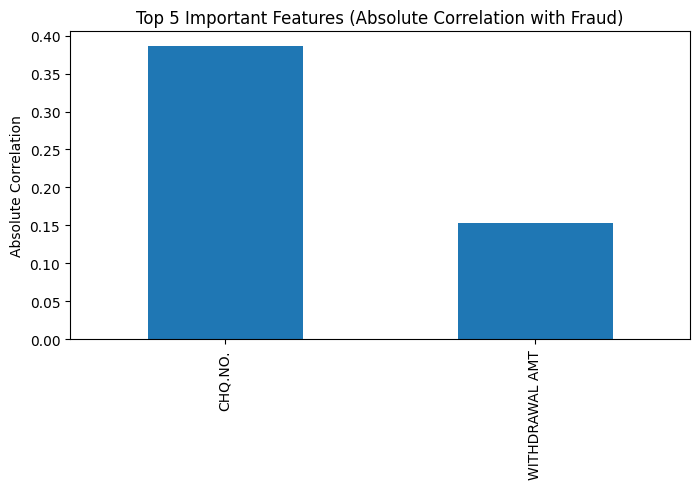

In [ ]:
plt.figure(figsize=(8,4))
top_features.head(5).plot(kind="bar")
plt.title("Top 5 Important Features (Absolute Correlation with Fraud)")
plt.ylabel("Absolute Correlation")
plt.show()

In [ ]:
def zscore_outliers(series, threshold=3):
    mean = series.mean()
    std = series.std()
    z = (series - mean) / std
    return abs(z) > threshold

In [ ]:
df_z = df.copy()
results = []

for col in important_cols:
    mask = zscore_outliers(df_z[col], threshold=3)
    total_outliers = mask.sum()
    fraud_outliers = ((df_z["BALANCE AMT"] == 1) & (mask)).sum()
    normal_outliers = ((df_z["BALANCE AMT"] == 0) & (mask)).sum()
    results.append({
        "Feature": col,
        "Total_Outliers": total_outliers,
        "Fraud_Outliers": fraud_outliers,
        "Normal_Outliers": normal_outliers
    })

In [ ]:
results_df = pd.DataFrame(results)
print(results_df)

          Feature  Total_Outliers  Fraud_Outliers  Normal_Outliers
0         CHQ.NO.              23               0                0
1  WITHDRAWAL AMT            1037               0                0


In [ ]:
total_outliers = (np.abs(stats.zscore(df['WITHDRAWAL AMT'].dropna())) > 3).sum()

print("Final number of outliers in bank_transaction_dataset:", total_outliers)


Final number of outliers in bank_transaction_dataset: 1037
